In [7]:
library(DESeq2)
library(dplyr)
library(data.table)
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



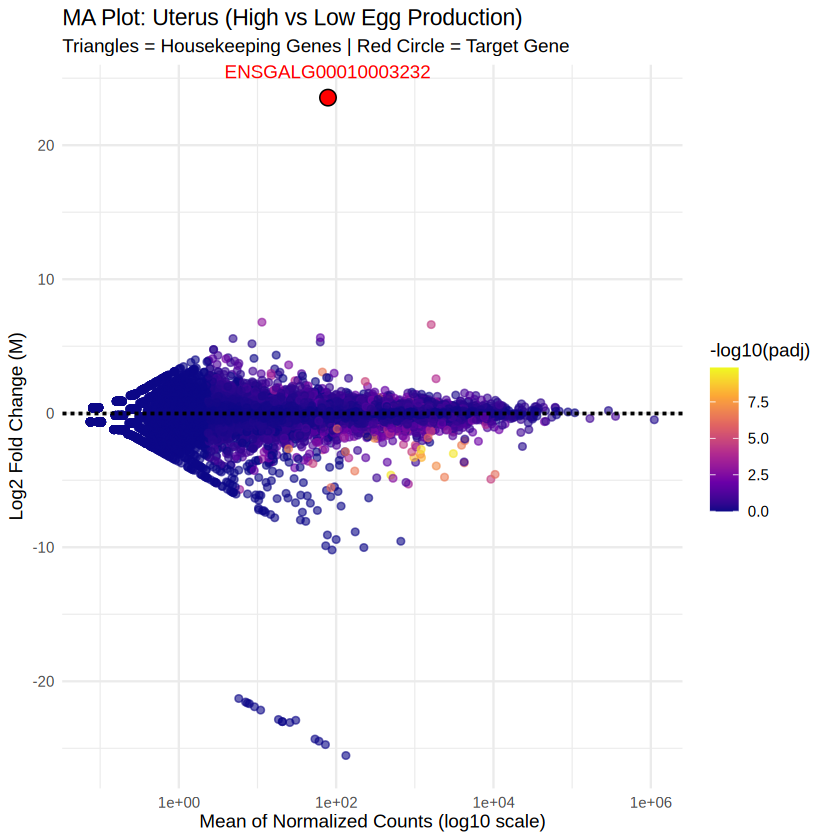

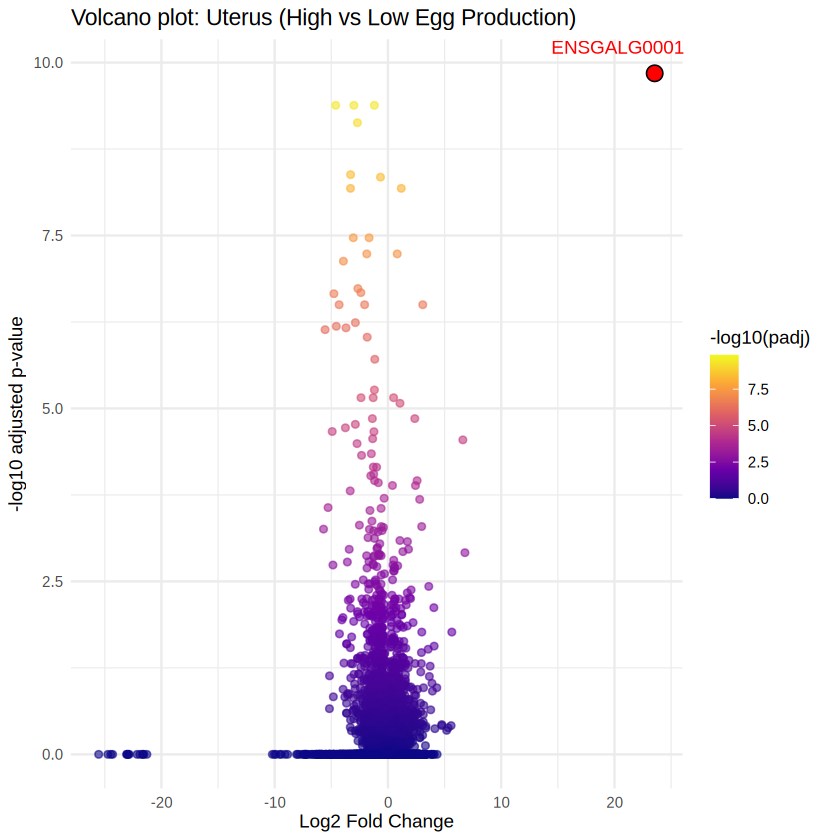

In [18]:
# ============================================================================
# 2. Load Data
# ============================================================================
base_dir <- "/home/johan/output/chicken/"
counts <- fread(file.path(base_dir, "combined_HTseq_report.tsv"))
metadata <- fread(file.path(base_dir, "metadata.csv"))

# ============================================================================
# 3. Format Count Matrix
# ============================================================================
gene_col <- names(counts)[1]
counts_df <- as.data.frame(counts)
rownames(counts_df) <- counts_df[[gene_col]]
counts_df[[gene_col]] <- NULL
counts_df <- as.matrix(counts_df)

# ============================================================================
# 4. Clean Metadata & Identify Sample Column
# ============================================================================
metadata <- as.data.frame(metadata)

# Find the column that contains the sample IDs
sample_col <- names(metadata)[sapply(names(metadata), function(col) any(as.character(metadata[[col]]) %in% colnames(counts_df)))][1]

if (is.na(sample_col)) {
  stop("No column in metadata contains sample names matching the count matrix columns.")
}
rownames(metadata) <- as.character(metadata[[sample_col]])

# ============================================================================
# 5. Subset for UTERUS and Align Samples
# ============================================================================
metadata_uterus <- metadata[trimws(as.character(metadata$tissue)) == "uterus", , drop = FALSE]

if (nrow(metadata_uterus) == 0) {
  stop("No 'uterus' samples found in the tissue column.")
}

shared_samples <- intersect(colnames(counts_df), rownames(metadata_uterus))
counts_uterus <- counts_df[, shared_samples, drop = FALSE]
metadata_uterus <- metadata_uterus[shared_samples, , drop = FALSE]

# ============================================================================
# 6. Format Condition Column (Egg Production)
# ============================================================================
metadata_uterus$egg_production <- trimws(as.character(metadata_uterus$egg_production))
metadata_uterus$egg_production <- factor(metadata_uterus$egg_production)

if ("low" %in% levels(metadata_uterus$egg_production)) {
  metadata_uterus$egg_production <- relevel(metadata_uterus$egg_production, ref = "low")
} else {
  stop("No 'low' level found in egg_production column.")
}

# ============================================================================
# 7. Build and Run DESeq2
# ============================================================================
dds <- DESeqDataSetFromMatrix(
  countData = counts_uterus,
  colData = metadata_uterus,
  design = ~ egg_production
)

dds <- DESeq(dds)
res <- results(dds, contrast = c("egg_production", "high", "low"))

# ============================================================================
# 8. Prepare Results for Plotting
# ============================================================================
target_gene <- "ENSGALG00010003232"

# REPLACE THESE WITH YOUR ACTUAL CHICKEN HOUSEKEEPING ENSEMBL IDs
housekeeping_genes <- c(
  "ENSGALG00000014442", # Example: GAPDH
  "ENSGALG00000008852", # Example: ACTB
  "ENSGALG000000XXXXX"  # Add more...
)

res_df <- as.data.frame(res)
res_df$gene <- rownames(res_df)

# Handle NAs and calculate negLogP for color gradients
res_df$padj[is.na(res_df$padj)] <- 1
res_df$negLogP <- -log10(res_df$padj)

# Flag housekeeping genes for easy highlighting
res_df$is_housekeeping <- res_df$gene %in% housekeeping_genes

# Remove genes with 0 baseMean (they can't be plotted on a log scale anyway)
res_df <- res_df[res_df$baseMean > 0, ]

# ============================================================================
# 9. ggplot2 MA Plot (Color coded & Housekeeping aligned)
# ============================================================================
# M (log2FoldChange) on Y-axis, A (baseMean) on X-axis (log scaled)
ma_plot <- ggplot(res_df, aes(x = baseMean, y = log2FoldChange)) +
  # Standard genes colored by adjusted p-value
  geom_point(aes(color = negLogP), alpha = 0.6, size = 1.5) +
  # Continuous color scale (yellow/green/purple gradient works well for p-values)
  scale_color_viridis_c(name = "-log10(padj)", option = "plasma") +
  # Log scale for the X-axis (standard for MA plots)
  scale_x_log10() +
  # M = 0 reference line to check normalization alignment
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", linewidth = 0.8) +
  
  # Highlight Housekeeping Genes (Green triangles with black borders)
  geom_point(data = res_df[res_df$is_housekeeping, ],
             fill = "green", shape = 24, size = 3, color = "black") +
  
  # Highlight Gene of Interest (Red circle)
  geom_point(data = res_df[res_df$gene == target_gene, ],
             fill = "red", shape = 21, size = 4, color = "black") +
  # Label the Target Gene
  geom_text(data = res_df[res_df$gene == target_gene, ],
            aes(label = gene), vjust = -1.5, color = "red") +
  
  theme_minimal() +
  labs(
    title = "MA Plot: Uterus (High vs Low Egg Production)",
    subtitle = "Triangles = Housekeeping Genes | Red Circle = Target Gene",
    x = "Mean of Normalized Counts (log10 scale)",
    y = "Log2 Fold Change (M)"
  )

print(ma_plot)

# ============================================================================
# 10. Volcano Plot (ggplot2)
# ============================================================================
volcano_plot <- ggplot(res_df, aes(x = log2FoldChange, y = negLogP)) +
  geom_point(aes(color = negLogP), alpha = 0.6) +
  scale_color_viridis_c(name = "-log10(padj)", option = "plasma") +
  
  # Highlight the specific gene
  geom_point(data = res_df[res_df$gene == target_gene, ],
             fill = "red", shape = 21, size = 4, color="black") +
  # Label the specific gene
  geom_text(data = res_df[res_df$gene == target_gene, ],
            aes(label = gene), vjust = -1.5, color = "red") +
  theme_minimal() +
  labs(
    title = "Volcano plot: Uterus (High vs Low Egg Production)",
    x = "Log2 Fold Change",
    y = "-log10 adjusted p-value"
  )

print(volcano_plot)